In [1]:
# Standard library imports
import sys
import os

# Third-party imports
import pandas as pd
import matplotlib.pyplot as plt

# Setup path for src imports
notebooks_dir = os.path.dirname(os.path.abspath('__file__'))
root_dir = os.path.dirname(notebooks_dir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.training import train_gaussian_process
from src.evaluation import calculate_metrics
from src.visualisation import plot_actual_vs_predicted


# importing processed datasets for ML

X_train_stress = pd.read_csv("ml_ready_data/X_train_stress.csv")
X_test_stress = pd.read_csv("ml_ready_data/X_test_stress.csv")
y_train_stress = pd.read_csv("ml_ready_data/y_train_stress.csv").squeeze("columns")
y_test_stress = pd.read_csv("ml_ready_data/y_test_stress.csv").squeeze("columns")

X_train_deflection = pd.read_csv("ml_ready_data/X_train_deflection.csv")
X_test_deflection = pd.read_csv("ml_ready_data/X_test_deflection.csv")
y_train_deflection = pd.read_csv("ml_ready_data/y_train_deflection.csv").squeeze("columns")
y_test_deflection = pd.read_csv("ml_ready_data/y_test_deflection.csv").squeeze("columns")

print("Stress model     -> Train:", X_train_stress.shape, " Test:", X_test_stress.shape)
print("Deflection model -> Train:", X_train_deflection.shape, " Test:", X_test_deflection.shape)

Stress model     -> Train: (64, 6)  Test: (17, 6)
Deflection model -> Train: (64, 6)  Test: (17, 6)


In [2]:
# Importing important libraries

print('All libraries loaded...')

All libraries loaded...


# Stress Model

In [3]:
gpr_stress = train_gaussian_process(X_train_stress, y_train_stress)

pred_gpr_stress = gpr_stress.predict(X_test_stress) / 1e6  # Pa -> MPa
y_test_stress_mpa = y_test_stress / 1e6

metrics = calculate_metrics(y_test_stress, gpr_stress.predict(X_test_stress), unit_divisor=1e6)
print(f"GPR Stress -> MAE: {metrics['MAE']:.4f} MPa, RMSE: {metrics['RMSE']:.4f} MPa, R²: {metrics['R2']:.4f}")

C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 18 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 16 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


GPR Stress -> MAE: 0.0013 MPa, RMSE: 0.0016 MPa, R²: 1.0000


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Deformation Model

In [4]:
gpr_deflection = train_gaussian_process(X_train_deflection, y_train_deflection)

pred_gpr_defl = gpr_deflection.predict(X_test_deflection) * 1000  # m -> mm
y_test_defl_mm = y_test_deflection * 1000

metrics = calculate_metrics(y_test_deflection, gpr_deflection.predict(X_test_deflection), unit_divisor=0.001)
print(f"GPR Deflection -> MAE: {metrics['MAE']:.4f} mm, RMSE: {metrics['RMSE']:.4f} mm, R²: {metrics['R2']:.4f}")

C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 23 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 16 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 33 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


GPR Deflection -> MAE: 0.0016 mm, RMSE: 0.0031 mm, R²: 1.0000


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Plots

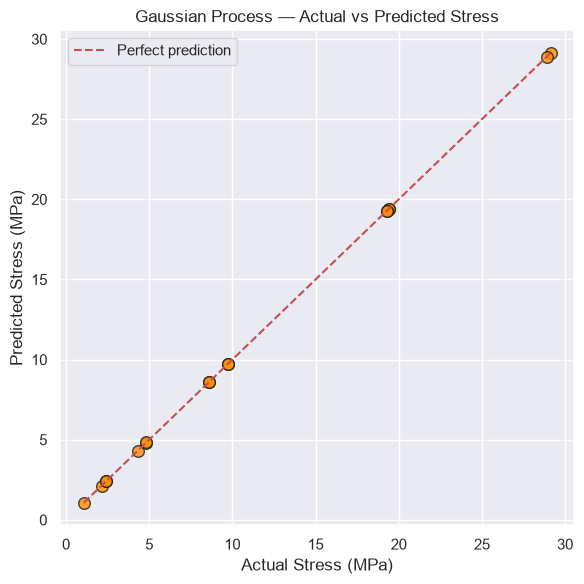

In [5]:
# Stress model plot using src visualization
plot_actual_vs_predicted(
    y_test_stress_mpa, pred_gpr_stress,
    xlabel="Actual Stress (MPa)",
    ylabel="Predicted Stress (MPa)",
    title="Gaussian Process — Actual vs Predicted Stress",
    color="darkorange"
)
plt.show()

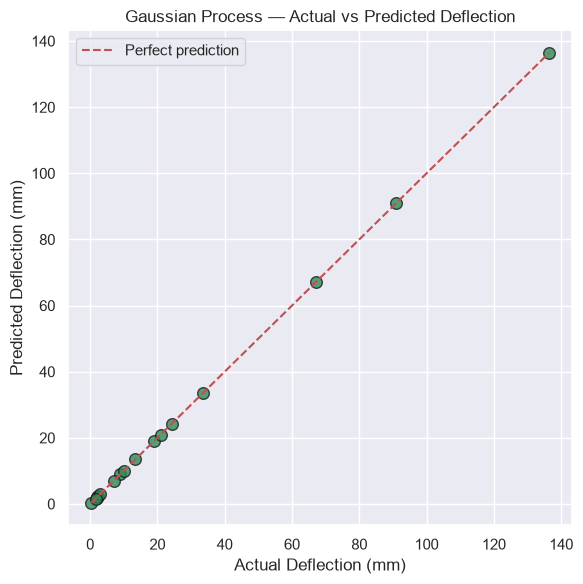

In [6]:
# Deflection model plot using src visualization
plot_actual_vs_predicted(
    y_test_defl_mm, pred_gpr_defl,
    xlabel="Actual Deflection (mm)",
    ylabel="Predicted Deflection (mm)",
    title="Gaussian Process — Actual vs Predicted Deflection",
    color="seagreen"
)
plt.show()